<a href="https://colab.research.google.com/github/zubaeteee20210205109-droid/Trial/blob/main/Skin_Cancer_ISIC_9_2nd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.callbacks import *

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

import seaborn as sns

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [2]:
dataset_path = "/content/drive/MyDrive/Skin cancer ISIC The International Skin Imaging Collaboration"

In [3]:
IMG_SIZE = 300
BATCH_SIZE = 16

train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

NUM_CLASSES = train_generator.num_classes
print("Classes:", NUM_CLASSES)

Found 1887 images belonging to 2 classes.
Found 470 images belonging to 2 classes.
Classes: 2


In [4]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(9.93157894736842), 1: np.float64(0.5265066964285714)}


In [5]:
input_layer = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# EfficientNetB3
efficientnet = EfficientNetB3(
    weights='imagenet',
    include_top=False,
    input_tensor=input_layer
)

# DenseNet121
densenet = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_tensor=input_layer
)

efficientnet.trainable = False
densenet.trainable = False

x1 = GlobalAveragePooling2D()(efficientnet.output)
x2 = GlobalAveragePooling2D()(densenet.output)

fusion = Concatenate()([x1, x2])

fusion = BatchNormalization()(fusion)

fusion = Dense(
    1024,
    activation='relu'
)(fusion)

fusion = Dropout(0.4)(fusion)

fusion = Dense(
    512,
    activation='relu'
)(fusion)

fusion = Dropout(0.3)(fusion)

output = Dense(
    NUM_CLASSES,
    activation='softmax'
)(fusion)

model = Model(
    inputs=input_layer,
    outputs=output
)

model.summary()

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 306, 306,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 150, 150,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 150, 150,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 150, 150,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 152, 152,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 75, 75,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 75, 75,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 75, 75,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 75, 75,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 75, 75,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 75, 75,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 75, 75,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 75, 75,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 75, 75,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 75, 75,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 75, 75,    │     12,288 │ conv2_block2_0_r

 Total params: 20,979,569 (80.03 MB)

 Trainable params: 3,153,410 (12.03 MB)

 Non-trainable params: 17,826,159 (68.00 MB)

In [6]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/best_skin_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

earlystop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=4,
    verbose=1
)

callbacks = [
    checkpoint,
    earlystop,
    reduce_lr
]

In [8]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.7124 - loss: 0.9878
Epoch 1: val_accuracy improved from None to 0.92979, saving model to /content/drive/MyDrive/best_skin_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/best_skin_model.keras
118/118 ━━━━━━━━━━━━━━━━━━━━ 1429s 12s/step - accuracy: 0.6534 - loss: 0.9240 - val_accuracy: 0.9298 - val_loss: 0.4942 - learning_rate: 1.0000e-04
Epoch 2/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.5976 - loss: 0.8379
Epoch 2: val_accuracy did not improve from 0.92979
118/118 ━━━━━━━━━━━━━━━━━━━━ 1319s 11s/step - accuracy: 0.6290 - loss: 0.7616 - val_accuracy: 0.6277 - val_loss: 0.6536 - learning_rate: 1.0000e-04
Epoch 3/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.6662 - loss: 0.7824
Epoch 3: val_accuracy did not improve from 0.92979
118/118 ━━━━━━━━━━━━━━━━━━━━ 1320s 11s/step - accuracy: 0.6486 - loss: 0.7886 - val_accuracy: 0.4277 - val_loss: 0.8155 - learning_rate: 1.0000e-04
Epoch

In [10]:
efficientnet.trainable = True
densenet.trainable = True

for layer in efficientnet.layers[:-30]:
    layer.trainable = False

for layer in densenet.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.7338 - loss: 0.8856
Epoch 1: val_accuracy did not improve from 0.92979
118/118 ━━━━━━━━━━━━━━━━━━━━ 1494s 12s/step - accuracy: 0.7260 - loss: 0.9534 - val_accuracy: 0.3447 - val_loss: 0.7914 - learning_rate: 1.0000e-05
Epoch 2/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.6591 - loss: 0.7163
Epoch 2: val_accuracy did not improve from 0.92979
118/118 ━━━━━━━━━━━━━━━━━━━━ 1425s 12s/step - accuracy: 0.6200 - loss: 0.7753 - val_accuracy: 0.2872 - val_loss: 0.8647 - learning_rate: 1.0000e-05
Epoch 3/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.6058 - loss: 0.8100
Epoch 3: val_accuracy did not improve from 0.92979
118/118 ━━━━━━━━━━━━━━━━━━━━ 1463s 12s/step - accuracy: 0.5957 - loss: 0.8354 - val_accuracy: 0.6596 - val_loss: 0.6376 - learning_rate: 1.0000e-05
Epoch 4/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.5836 - loss: 0.8081
Epoch 4: val_accuracy did not improve from 0.92979

Epoch 4: Re

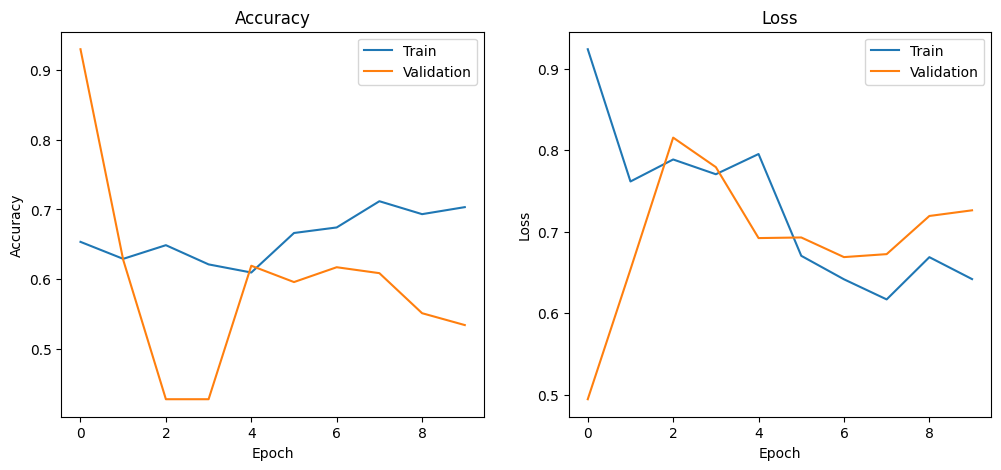

In [11]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

In [12]:
loss, acc = model.evaluate(val_generator)

print("Validation Loss :", loss)
print("Validation Accuracy :", acc)

30/30 ━━━━━━━━━━━━━━━━━━━━ 273s 9s/step - accuracy: 0.3511 - loss: 0.7865
Validation Loss : 0.7865443825721741
Validation Accuracy : 0.3510638177394867


In [13]:
val_generator.reset()

y_pred = model.predict(val_generator)

y_pred_classes = np.argmax(y_pred, axis=1)

y_true = val_generator.classes

30/30 ━━━━━━━━━━━━━━━━━━━━ 300s 9s/step


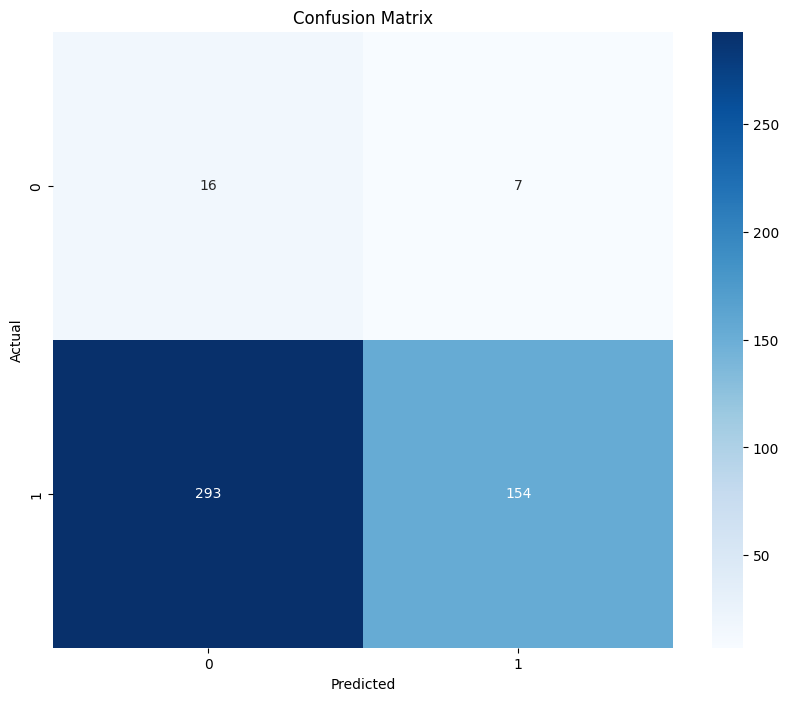

In [14]:
cm = confusion_matrix(
    y_true,
    y_pred_classes
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [15]:
class_names = list(
    train_generator.class_indices.keys()
)

print(
    classification_report(
        y_true,
        y_pred_classes,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

        Test       0.05      0.70      0.10        23
       Train       0.96      0.34      0.51       447

    accuracy                           0.36       470
   macro avg       0.50      0.52      0.30       470
weighted avg       0.91      0.36      0.49       470



In [22]:
print(y_true.shape)
print(y_pred.shape)
print(y_true_bin.shape)
print(np.unique(y_true))

(470,)
(470, 2)
(470, 1)
[0 1]


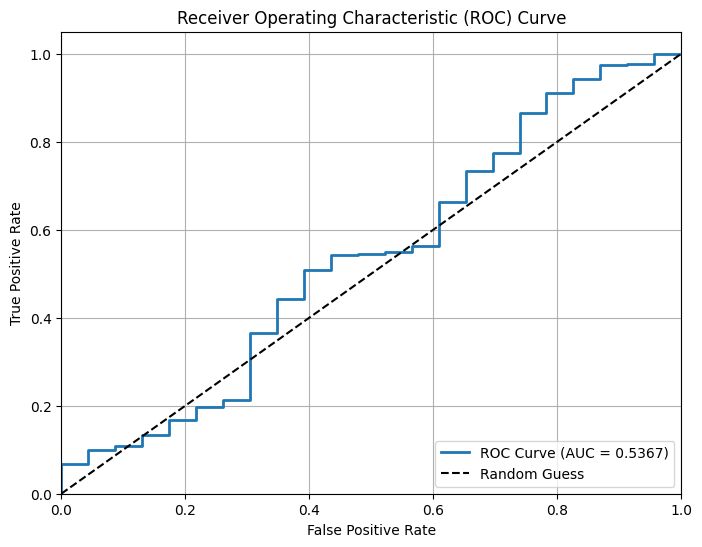

AUC Score: 0.5367


In [18]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc

# Positive class probability
y_score = y_pred[:, 1]

# ROC calculation
fpr, tpr, thresholds = roc_curve(y_true, y_score)

# AUC calculation
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'ROC Curve (AUC = {roc_auc:.4f})'
)

# Random classifier line
plt.plot(
    [0, 1],
    [0, 1],
    'k--',
    label='Random Guess'
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')

plt.legend(loc="lower right")
plt.grid(True)

plt.show()

# Print AUC Score
print("=" * 40)
print(f"AUC Score: {roc_auc:.4f}")
print("=" * 40)

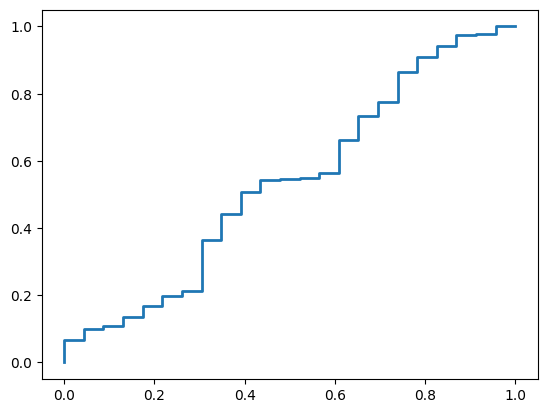

In [21]:
plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'{class_names[1]} (AUC = {roc_auc:.4f})'
)

In [23]:
best_acc = max(
    history.history['val_accuracy']
)

print("="*50)
print("BEST VALIDATION ACCURACY")
print(best_acc * 100)
print("="*50)

BEST VALIDATION ACCURACY
92.97872185707092


In [24]:
val_loss, val_acc = model.evaluate(val_generator)

print("=================================")
print("Final Validation Accuracy:", val_acc * 100)
print("=================================")

30/30 ━━━━━━━━━━━━━━━━━━━━ 257s 9s/step - accuracy: 0.3617 - loss: 0.7870
Final Validation Accuracy: 36.17021143436432
